In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [3]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [4]:
BASEDIR = {
    "incl" : "/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-21/",
    "Qbinned" : "/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-07-09/",
}
OUTDIR = os.path.join(BASEDIR["Qbinned"], 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
PROCESS = {"ttH" : {"label" : r"$ttH\to\gamma\gamma$"},
           "ttyy" : {"label" : r"$tt\gamma\gamma$"},
          }

In [5]:
SAMPLES = {
    "incl" : {
        "ttH" : "mgp8_pp_tth01j_5f_84TeV_haaexcl",
        "ttyy" : "mgp8_pp_ttaa01j_5f_84TeV",
#        "Vyy" : "mgp8_pp_Vaajj_HF_5f_84TeV",
    },
    "Qbinned" : {
        "ttH" : { 
            "Q_0_1000" : "mgp8_pp_tth_5f_Q_0_1000_84TeV_haaexcl",
            "Q_1000_3000" : "mgp8_pp_tth_5f_Q_1000_3000_84TeV_haaexcl",
            "Q_3000_10000" : "mgp8_pp_tth_5f_Q_3000_10000_84TeV_haaexcl",
            "Q_10000_84000" : "mgp8_pp_tth_5f_Q_10000_84000_84TeV_haaexcl",
        },
        "ttyy" : {
            "Q_0_500" : "mgp8_pp_ttaa_Q_0_500_5f_84TeV",
            "Q_500_1000" : "mgp8_pp_ttaa_Q_500_1000_5f_84TeV",
            "Q_1000_2000" : "mgp8_pp_ttaa_Q_1000_2000_5f_84TeV",
            "Q_2000_5000" : "mgp8_pp_ttaa_Q_2000_5000_5f_84TeV",
            "Q_5000_84000" : "mgp8_pp_ttaa_Q_5000_84000_5f_84TeV",
        },
#        "Vyy" : {
#            "Q_0_500" : "mgp8_pp_vaa_Q_0_500_5f_84TeV",
#            "Q_500_1000" : "mgp8_pp_vaa_Q_500_1000_5f_84TeV",
#            "Q_1000_2000" : "mgp8_pp_vaa_Q_1000_2000_5f_84TeV",
#            "Q_2000_5000" : "mgp8_pp_vaa_Q_2000_5000_5f_84TeV",
#            "Q_5000_84000" : "mgp8_pp_vaa_Q_5000_84000_5f_84TeV",
#        }
    }
}
PROCESS_DICT_ttH_Qbinned = {
        "mgp8_pp_tth_5f_Q_0_1000_84TeV_haaexcl": {
        "crossSection": 0.1017868,
        "kfactor": 1.0,
        "matchingEfficiency": 1.0
    },
        "mgp8_pp_tth_5f_Q_1000_3000_84TeV_haaexcl": {
        "crossSection": 0.1017868,
        "kfactor": 1.0,
        "matchingEfficiency": 1.0
    },
        "mgp8_pp_tth_5f_Q_3000_10000_84TeV_haaexcl": {
        "crossSection": 0.1017868,
        "kfactor": 1.0,
        "matchingEfficiency": 1.0
    },
        "mgp8_pp_tth_5f_Q_10000_84000_84TeV_haaexcl": {
        "crossSection": 0.1017868,
        "kfactor": 1.0,
        "matchingEfficiency": 1.0
    }
}

In [71]:
variables_list = ["n_photons", "n_muons", "n_electrons",
                  'pT_y1', 'pT_y2', 'rel_pT_y1', 'rel_pT_y2', 'm_yy', 'pT_yy', "n_leptons", "n_bjets",
                 "pT_b1", "pT_b2", "pT_l1", "weight", "eta_y1", "eta_y2"]

In [73]:
variables_dicts = {
    "pT_y1" : {"name":"pT_y1","title":"Leading photon p_{T} [GeV]","bin":40,"xmin":0.,"xmax":1000.,"latex":"Leading photon $p_{T}$ [GeV]"},
    "pT_y2" : {"name":"pT_y2","title":"Subleading photon p_{T} [GeV]","bin":40,"xmin":0.,"xmax":200.,"latex":"Subleading photon $p_{T}$ [GeV]"},
    "eta_y1" : {"name":"eta_y1","title":"Leading photon #eta","bin":40,"xmin":-6.0,"xmax":6.0,"latex":"Leading photon $\eta$"},
    "eta_y2" : {"name":"eta_y2","title":"Subleading photon #eta","bin":40,"xmin":-6.0,"xmax":6.0,"latex":"Subleading photon $\eta$"},
    "m_yy" :  {"name":"m_yy","title":"m_{#gamma#gamma} [GeV]","bin":100,"xmin":0.,"xmax":200., "latex":"$m_{\gamma\gamma}$ [GeV]"},
    "pT_yy" : {"name":"pT_yy","title":"p_{T}^{#gamma#gamma} [GeV]","bin":60,"xmin":0.,"xmax":2000.,"latex":"$p_{T}^{\gamma\gamma}$ [GeV]"},
    "pT_b1" : {"name":"pT_b1","title":"Leading b-jet p_{T} [GeV]","bin":40,"xmin":0.,"xmax":1000., "latex":"Leading b-jet $p_{T}$ [GeV]"},
    "pT_b2" : {"name":"pT_b2","title":"Subleading b-jet p_{T} [GeV]","bin":40,"xmin":0.,"xmax":1000., "latex":"Subleading b-jet $p_{T}$ [GeV]"},
    "pT_l1" : {"name":"pT_l1","title":"Leading lepton p_{T} [GeV]","bin":40,"xmin":0.,"xmax":1000., "latex":"Leading lepton $p_{T}$ [GeV]"},
}

In [74]:
process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [75]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [76]:
#process_dicts.append(PROCESS_DICT_ttH_Qbinned)

In [77]:
dfs = {}
sow = {}

In [78]:
# read samples before any cuts
for type, type_infos in SAMPLES.items() :
    dfs[type] = {}
    sow[type] = {}
    print(type)
    for sample, sample_infos in type_infos.items() :
        print("\t"+sample)
        if type=="incl" :
            inputname = os.path.join(BASEDIR[type], "final", sample_infos+"_nocuts.root")
            # read sum of weights
            f = ROOT.TFile.Open(inputname)
            sow[type][sample] = f.Get("SumOfWeights").GetVal()
            f.Close()
            # get sample dict
            for d in process_dicts :
                if sample_infos in list(d.keys()) :
                    process_dict = d.copy()
                    break
            with uproot.open(inputname) as f :
                awk = f["events"].arrays(expressions=variables_list, library="ak")
                dfs[type][sample] = ak.to_dataframe(awk)
                dfs[type][sample]["weight"] = dfs[type][sample]["weight"]/sow[type][sample]*process_dict[sample_infos]['crossSection']*process_dict[sample_infos]['kfactor']*process_dict[sample_infos]['matchingEfficiency']
        else :
            dfs[type][sample] = {}
            sow[type][sample] = {}
            for bin, bin_infos in sample_infos.items() :
                print("\t\t"+bin)
                inputname = os.path.join(BASEDIR[type], "final", bin_infos+"_nocuts.root")
                # read sum of weights
                f = ROOT.TFile.Open(inputname)
                sow[type][sample][bin] = f.Get("SumOfWeights").GetVal()
                f.Close()
                # get sample dict
                for d in process_dicts :
                    if bin_infos in list(d.keys()) :
                        process_dict = d.copy()
                        break
                with uproot.open(inputname) as f :
                    awk = f["events"].arrays(expressions=variables_list, library="ak")
                    dfs[type][sample][bin] = ak.to_dataframe(awk)
                    dfs[type][sample][bin]["weight"] = dfs[type][sample][bin]["weight"]/sow[type][sample][bin]*process_dict[bin_infos]['crossSection']*process_dict[bin_infos]['kfactor']*process_dict[bin_infos]['matchingEfficiency']

incl
	ttH
	ttyy
Qbinned
	ttH
		Q_0_1000
		Q_1000_3000
		Q_3000_10000
		Q_10000_84000
	ttyy
		Q_0_500
		Q_500_1000
		Q_1000_2000
		Q_2000_5000
		Q_5000_84000


In [24]:
sel_key= 'nocuts'
sel_label = "All events"

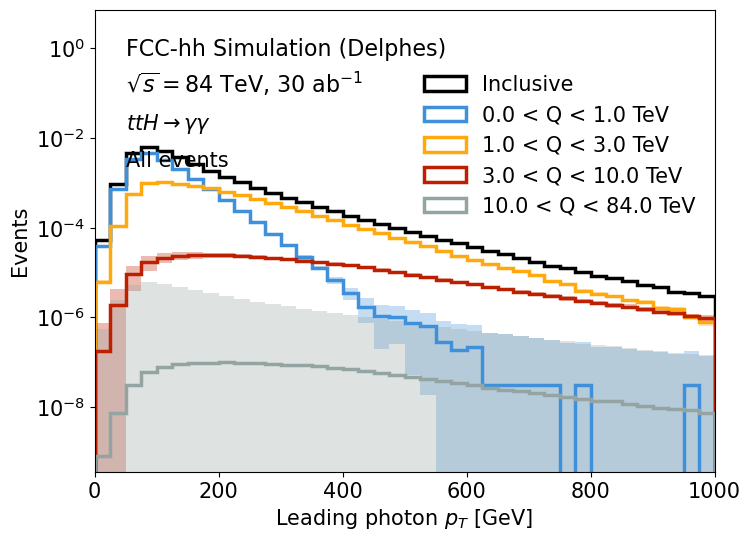

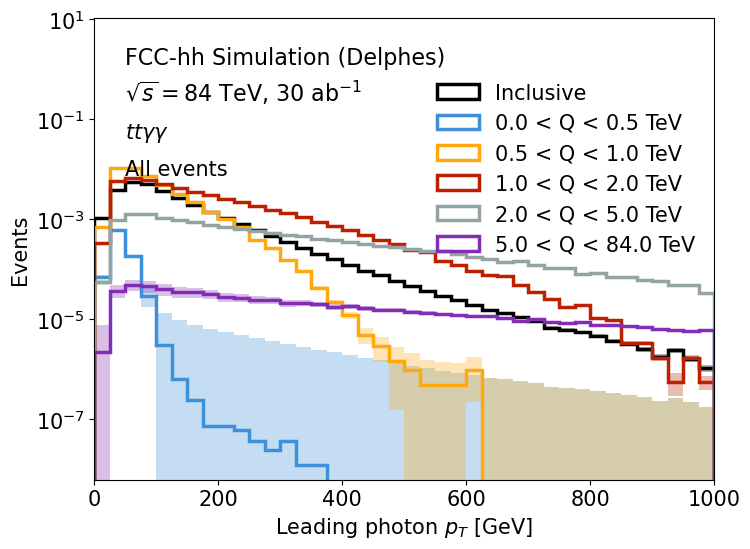

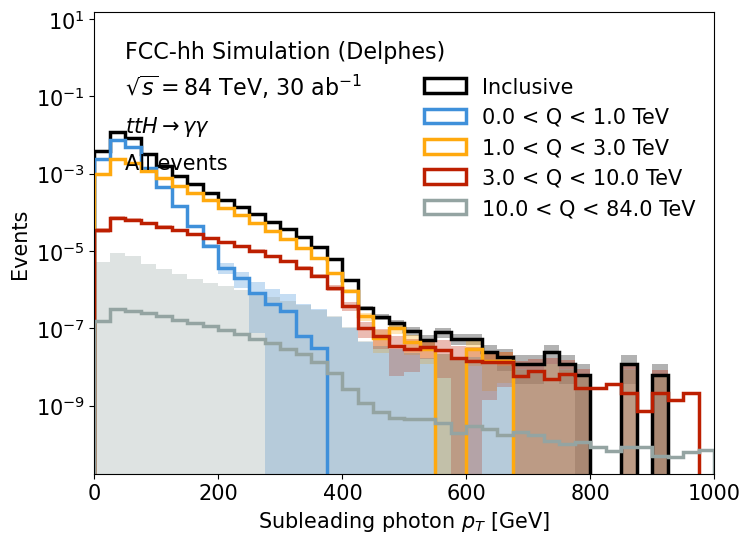

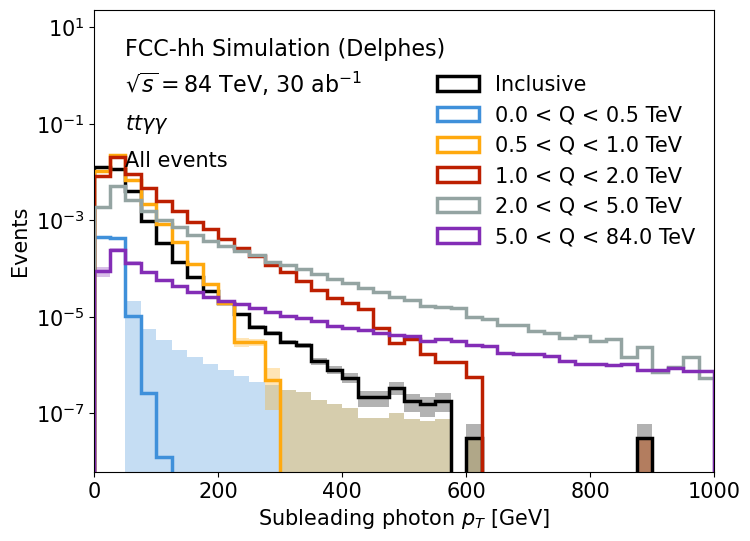

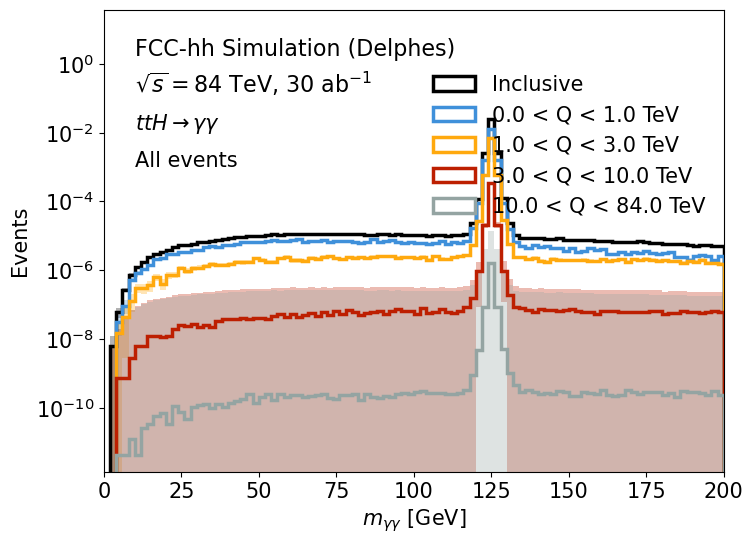

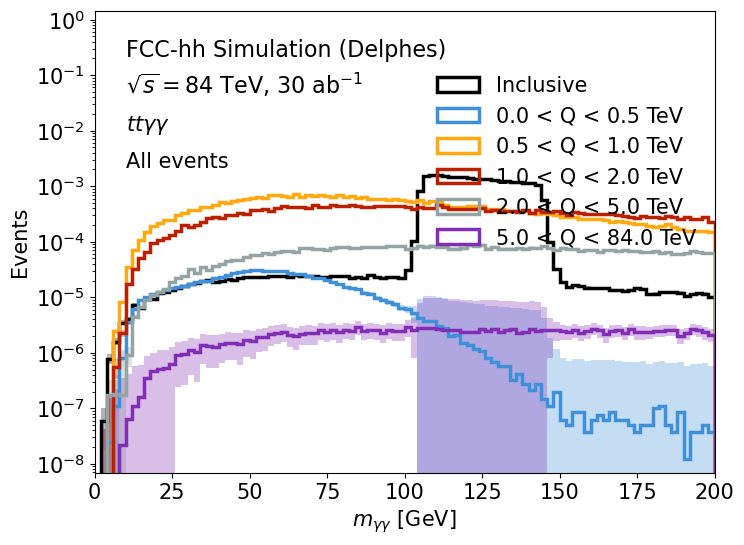

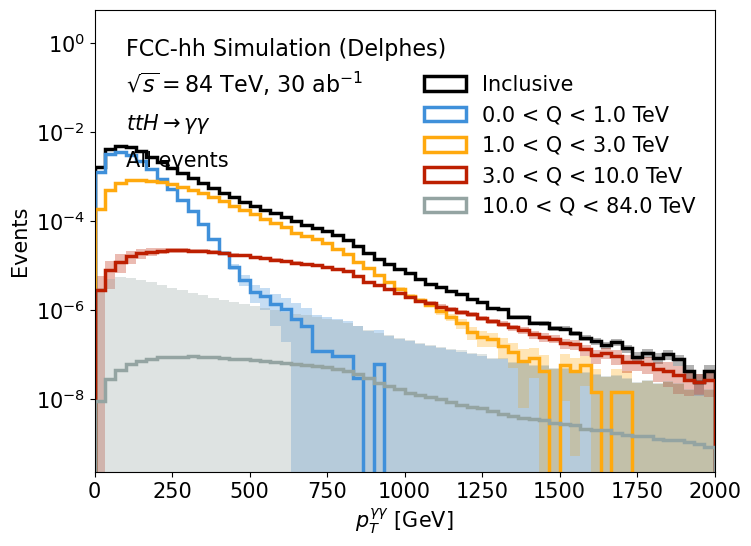

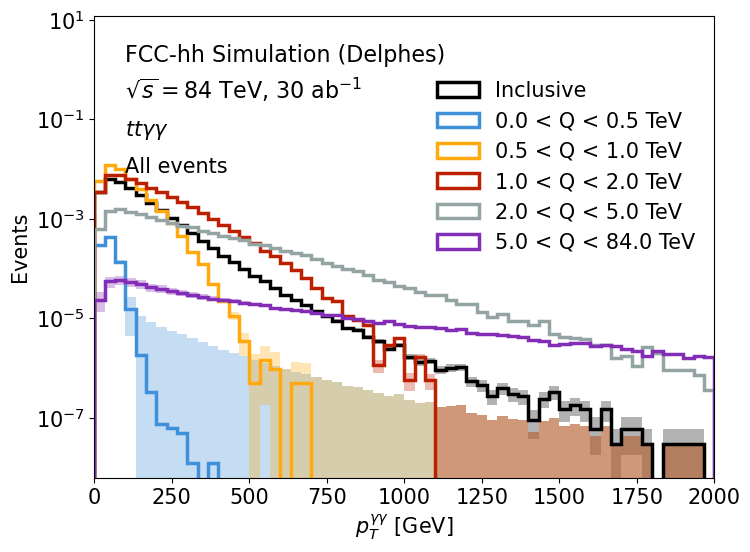

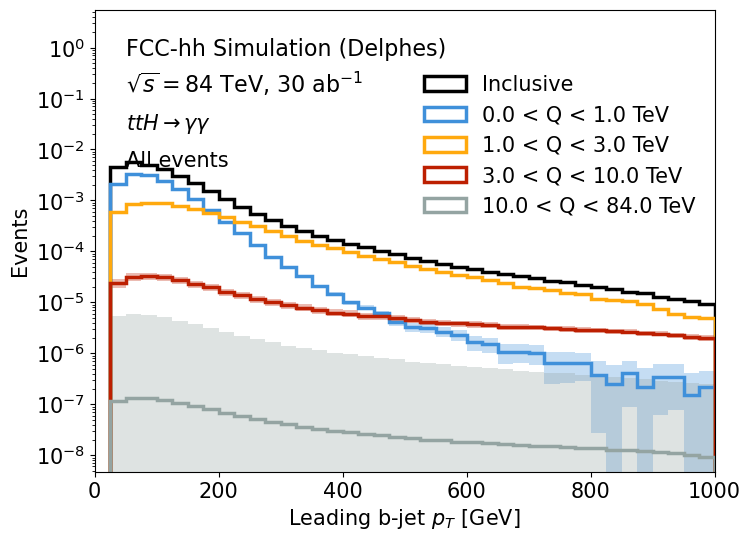

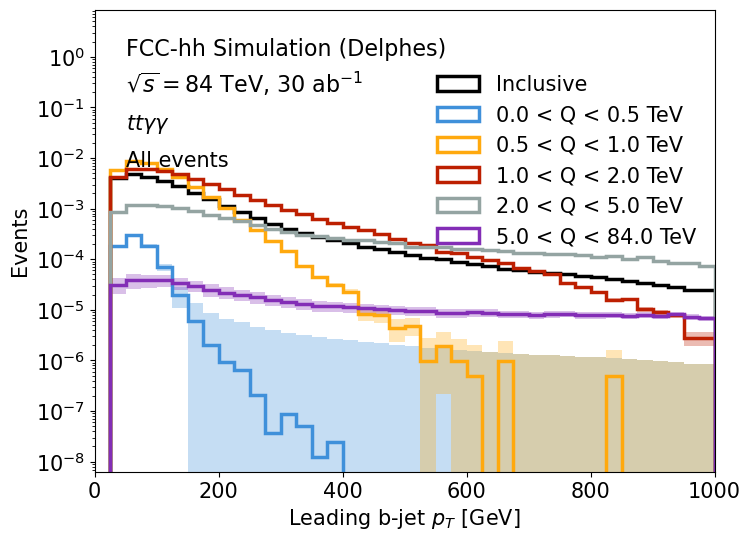

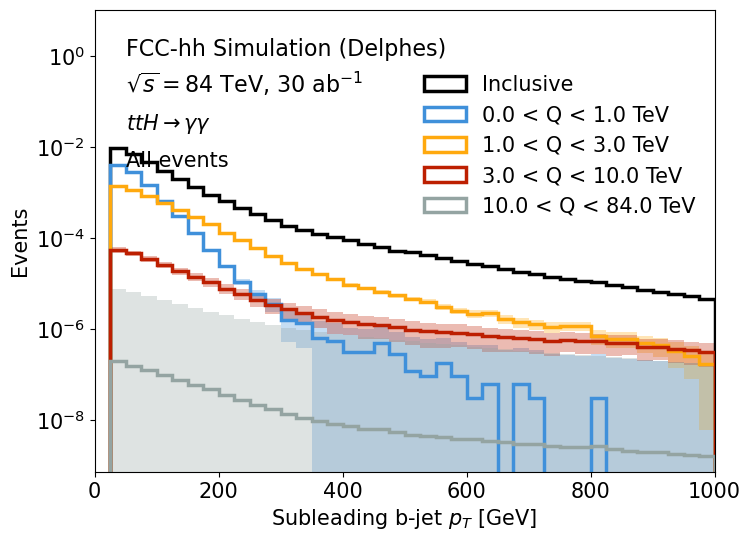

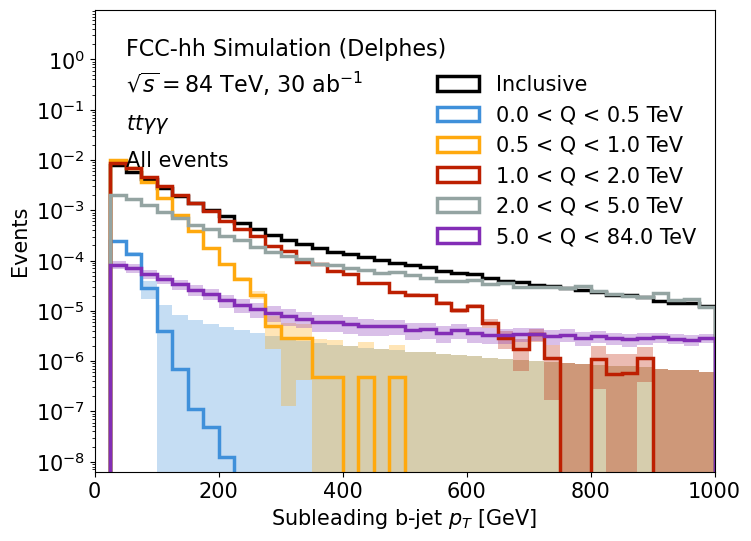

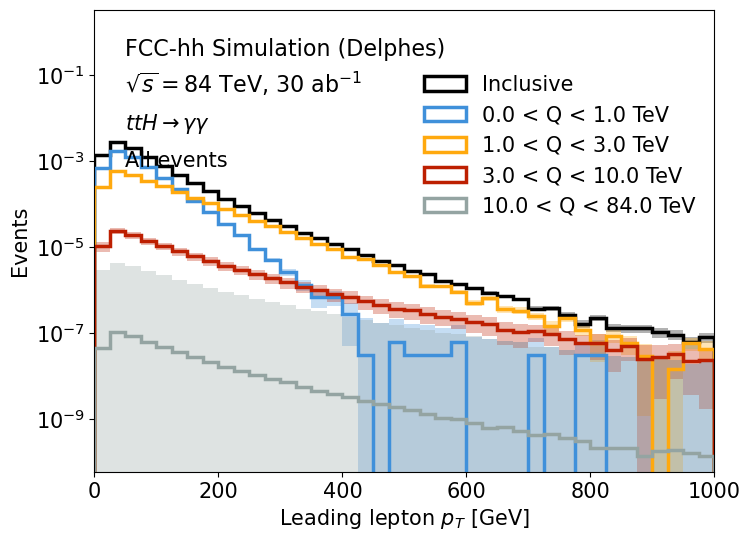

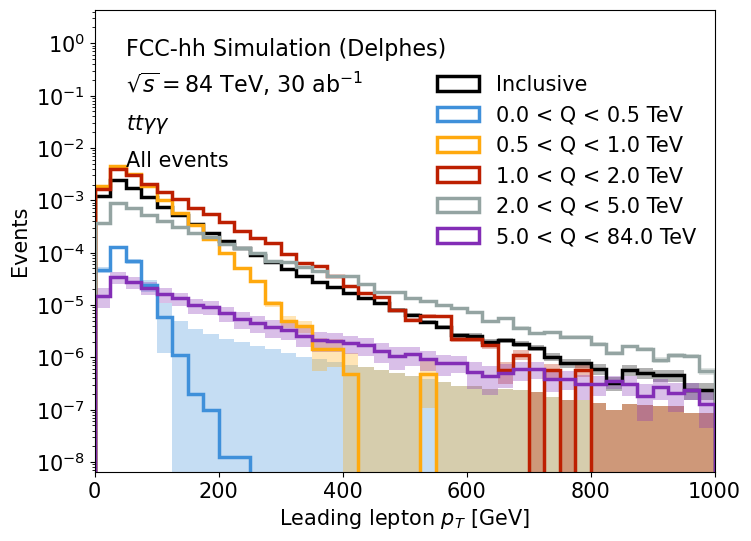

In [25]:
for variable, infos in variables_dicts.items() :
    if variable in variables_list :
        pass
    else :
        continue
    for p in list(PROCESS.keys()) :
        process_label = PROCESS[p]["label"]
        fig, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(8,6)
        )
        # first the inclusive sample in black
        bin_values, bin_edges, _ = ax.hist(dfs["incl"][p][variable], 
                                           weights=dfs["incl"][p]["weight"],
                                           bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                           histtype='step', linewidth=2.5, color='k',
                                           label="Inclusive")
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(dfs["incl"][p][variable], 
                                  weights=(dfs["incl"][p]["weight"])**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc='k')
        # then the q-binned samples in colors
        ibin=0
        for bin, df in dfs["Qbinned"][p].items() :
            bin_labels = bin.split("_")
            bin_min = float(bin_labels[1])*1e-3
            bin_max = float(bin_labels[2])*1e-3
            bin_label = str(bin_min) + " < Q < " +str(bin_max) + " TeV"
            bin_values, bin_edges, _ = ax.hist(df[variable], 
                                               weights=df["weight"],
                                               bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                               histtype='step', linewidth=2.5, color=color_sequence[ibin],
                                               label=bin_label)
            bin_unc, _ = np.histogram(dfs["incl"][p][variable], 
                                  weights=(dfs["incl"][p]["weight"])**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            bin_unc = np.sqrt(bin_unc)
            error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[ibin])
            ibin += 1

    
        ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=15)
        ax.text(0.05, 0.66, sel_label, transform=ax.transAxes, fontsize=15)

        ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.90))
        xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Events")

        ax.set_yscale("log")
        ax.set_xlim(infos["xmin"], infos["xmax"])
        ymin,ymax = ax.get_ylim() 
        ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*500)
    
        plotname = infos["name"]+"_"+p+"_Qbinned_samples_validation_"+sel_key
        #plt.savefig(os.path.join(OUTDIR, plotname+".pdf"), bbox_inches='tight')
        #plt.savefig(os.path.join(OUTDIR, plotname+".png"), bbox_inches='tight')
        plt.show()

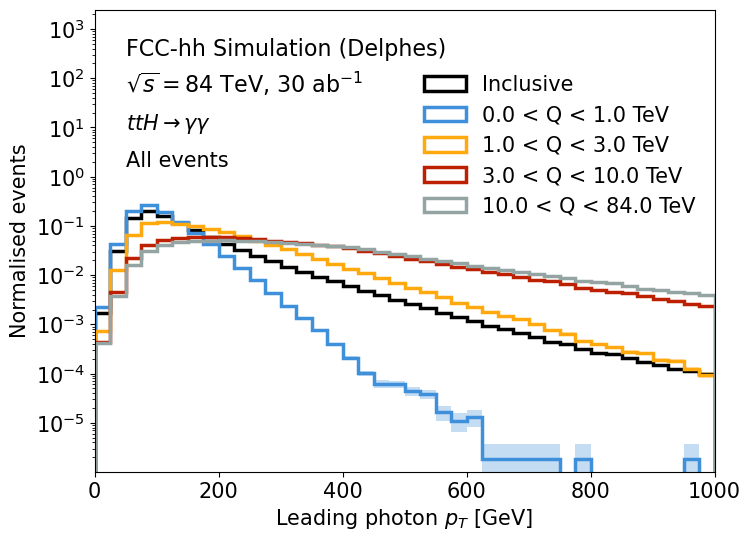

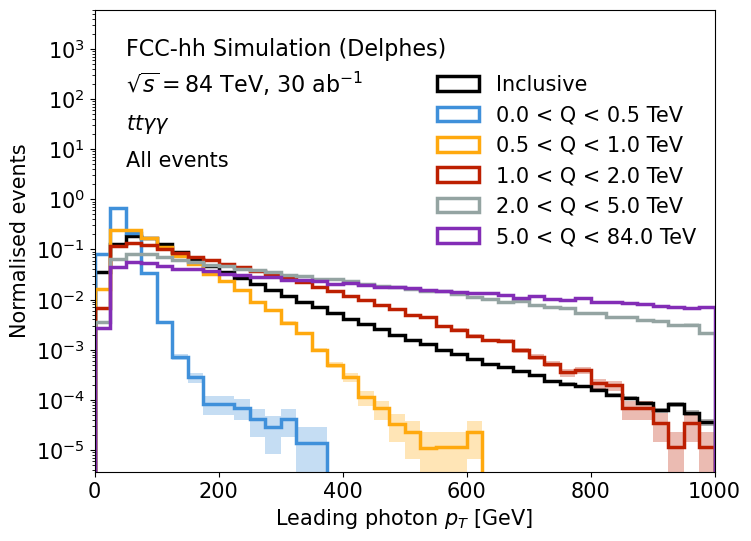

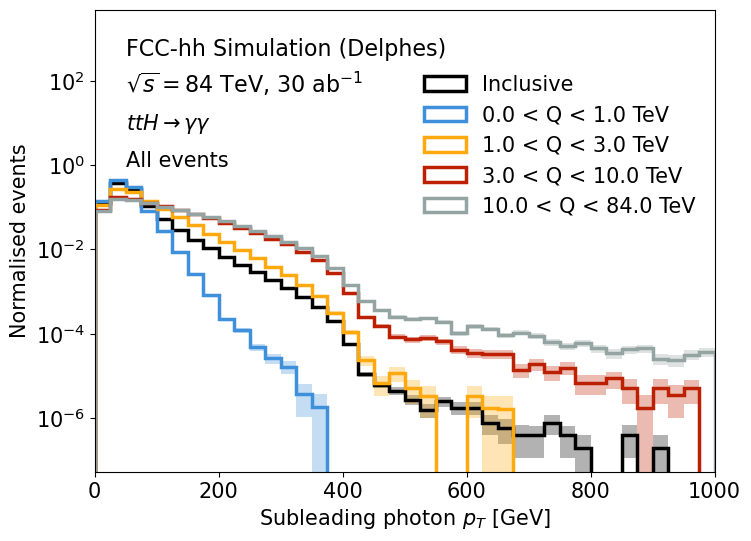

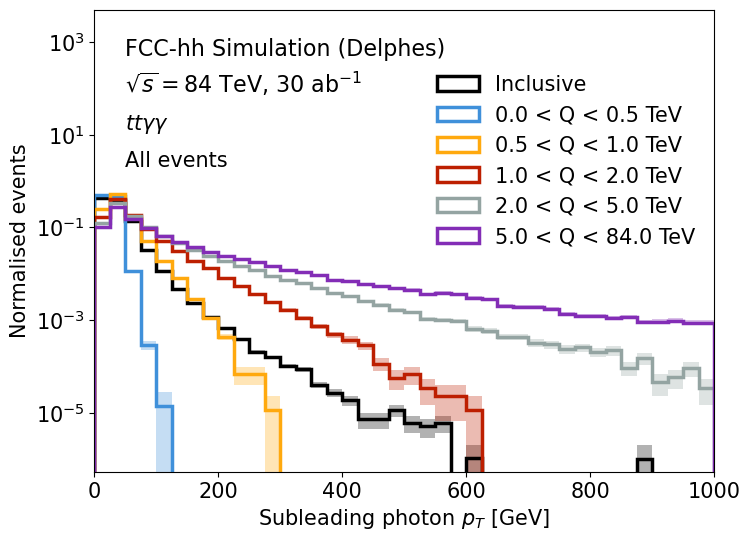

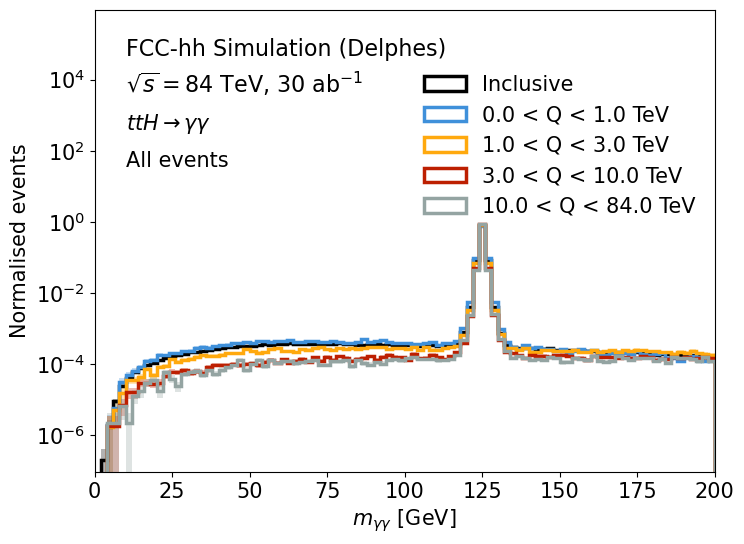

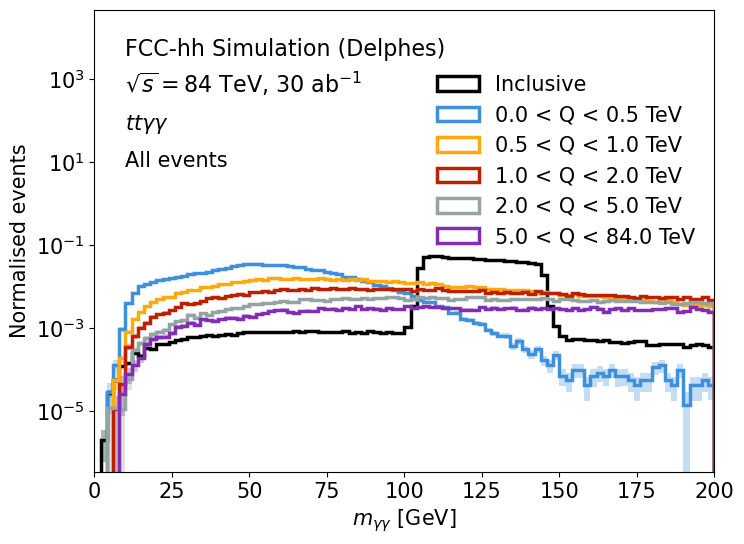

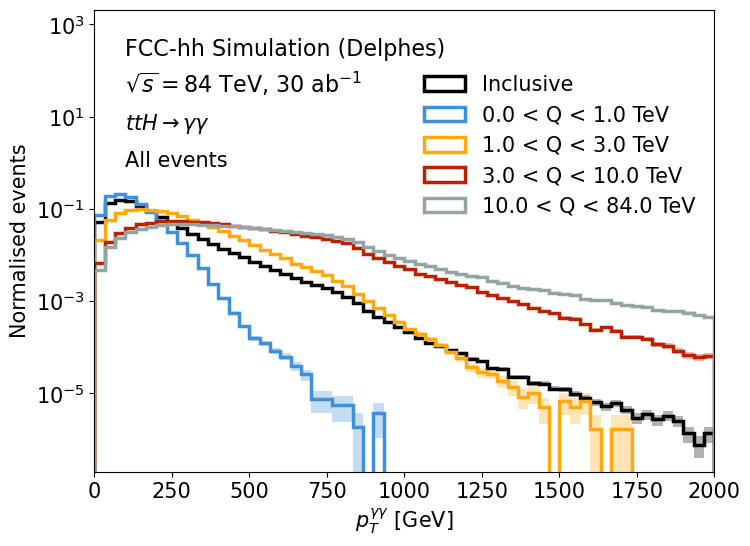

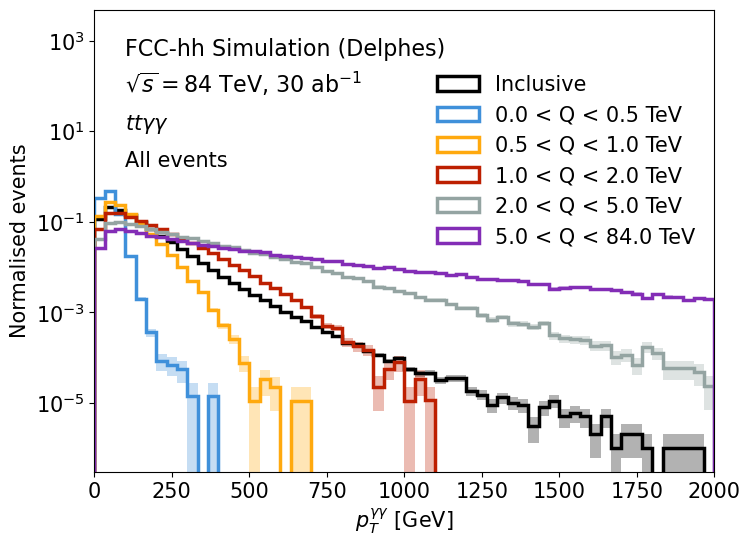

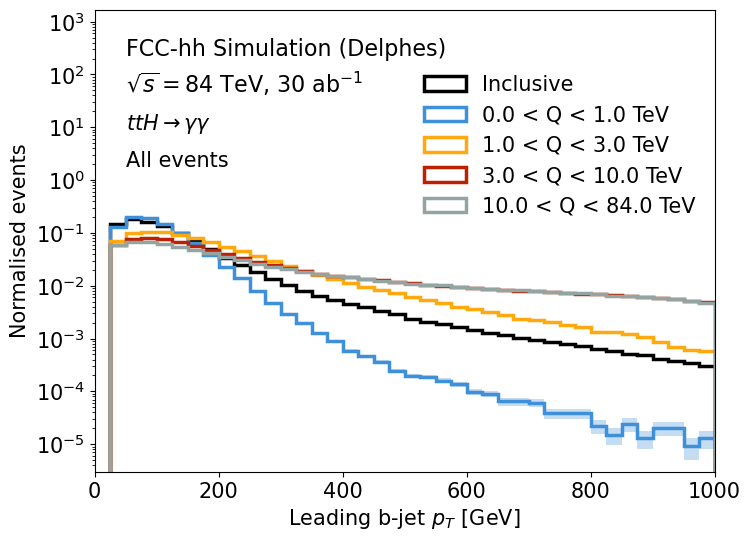

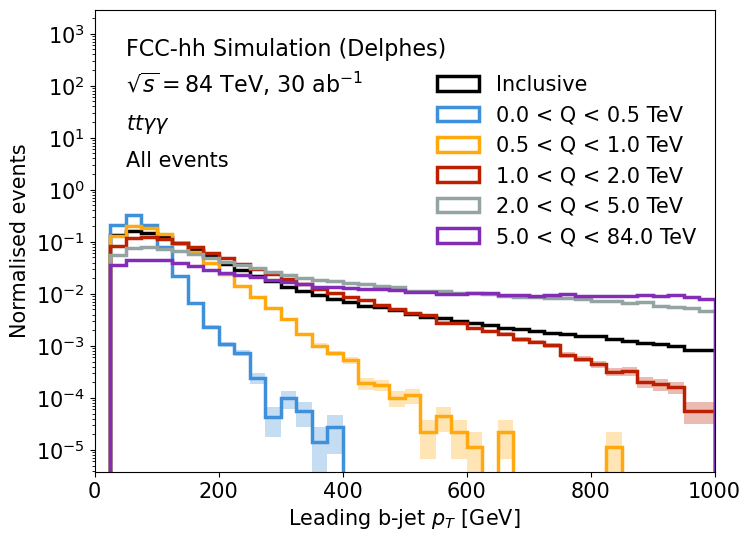

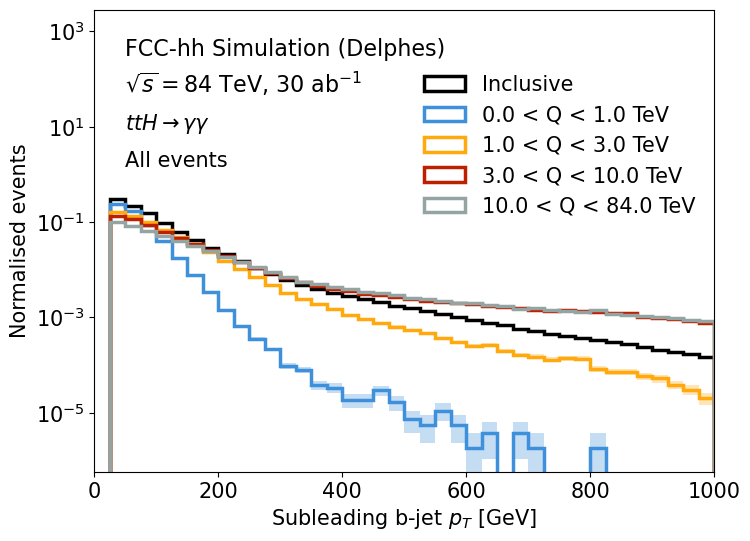

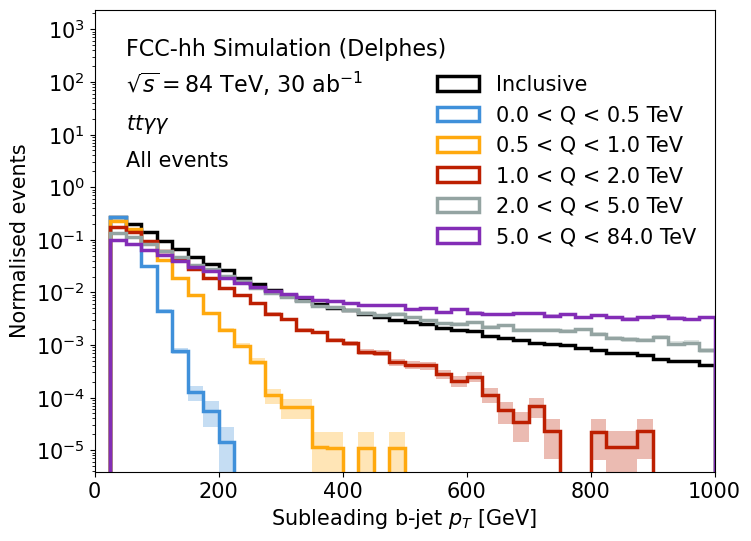

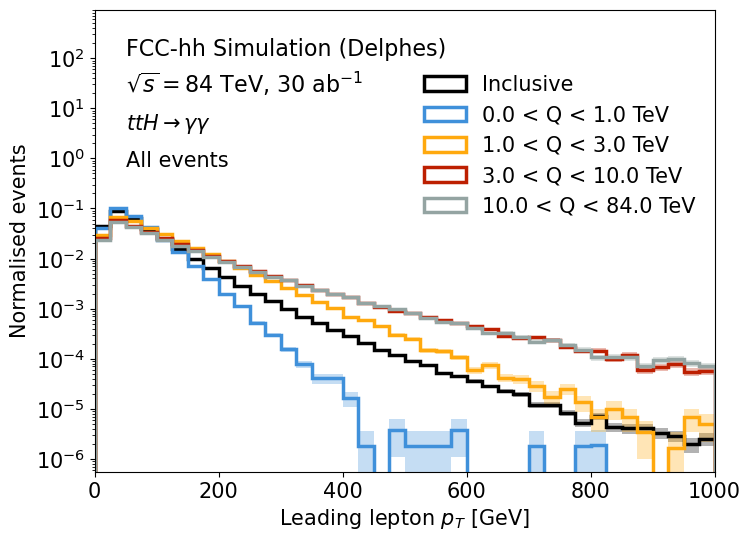

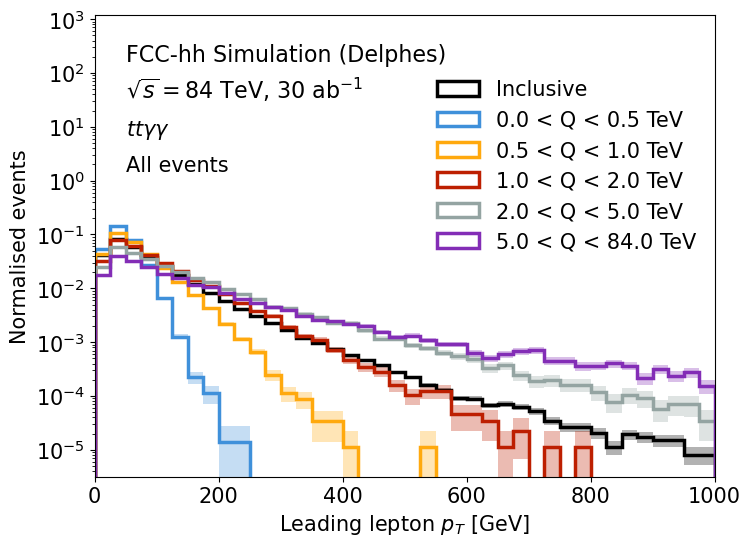

In [33]:
for variable, infos in variables_dicts.items() :
    if variable in variables_list :
        pass
    else :
        continue
    for p in list(PROCESS.keys()) :
        process_label = PROCESS[p]["label"]
        fig, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(8,6)
        )
        # first the inclusive sample in black
        bin_values, bin_edges, _ = ax.hist(dfs["incl"][p][variable], 
                                           weights=dfs["incl"][p]["weight"]/dfs["incl"][p]["weight"].sum(),
                                           bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                           histtype='step', linewidth=2.5, color='k',
                                           label="Inclusive")
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(dfs["incl"][p][variable], 
                                  weights=(dfs["incl"][p]["weight"]/dfs["incl"][p]["weight"].sum())**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc='k')
        # then the q-binned samples in colors
        ibin=0
        for bin, df in dfs["Qbinned"][p].items() :
            bin_labels = bin.split("_")
            bin_min = float(bin_labels[1])*1e-3
            bin_max = float(bin_labels[2])*1e-3
            bin_label = str(bin_min) + " < Q < " +str(bin_max) + " TeV"
            bin_values, bin_edges, _ = ax.hist(df[variable], 
                                               weights=df["weight"]/df["weight"].sum(),
                                               bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                               histtype='step', linewidth=2.5, color=color_sequence[ibin],
                                               label=bin_label)
            bin_unc, _ = np.histogram(df[variable], 
                                  weights=(df["weight"]/df["weight"].sum())**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            bin_unc = np.sqrt(bin_unc)
            error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[ibin])
            ibin += 1

    
        ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=15)
        ax.text(0.05, 0.66, sel_label, transform=ax.transAxes, fontsize=15)

        ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.90))
        xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Normalised events")

        ax.set_yscale("log")
        ax.set_xlim(infos["xmin"], infos["xmax"])
        ymin,ymax = ax.get_ylim() 
        N = 5e5 if variable == "m_yy" else 5e3
        ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*N)
    
        plotname = infos["name"]+"_"+p+"_Qbinned_samples_validation_normalised_events_"+sel_key
        plt.savefig(os.path.join(OUTDIR, plotname+".pdf"), bbox_inches='tight')
        plt.savefig(os.path.join(OUTDIR, plotname+".png"), bbox_inches='tight')
        plt.show()

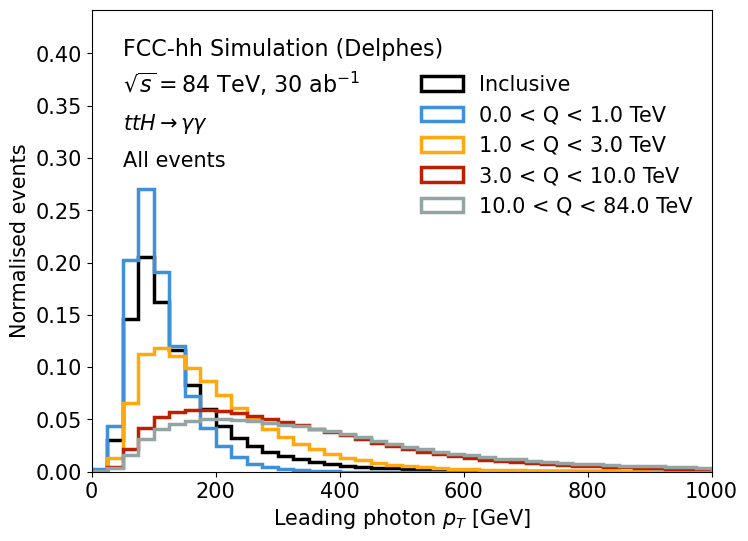

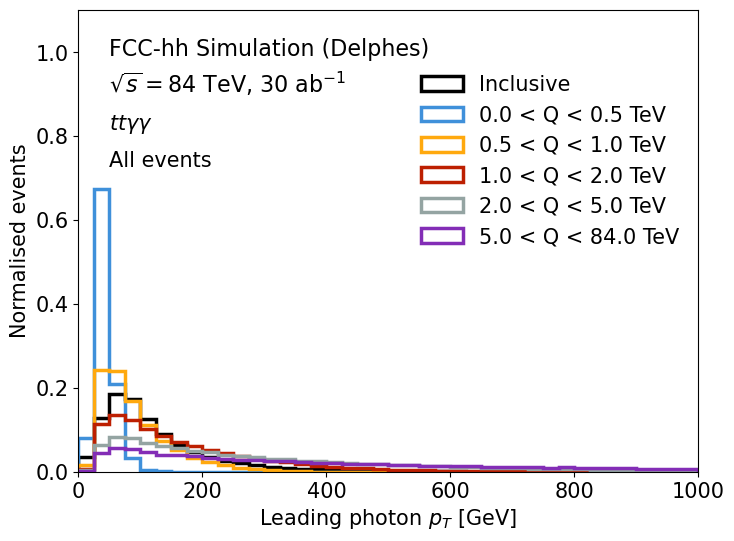

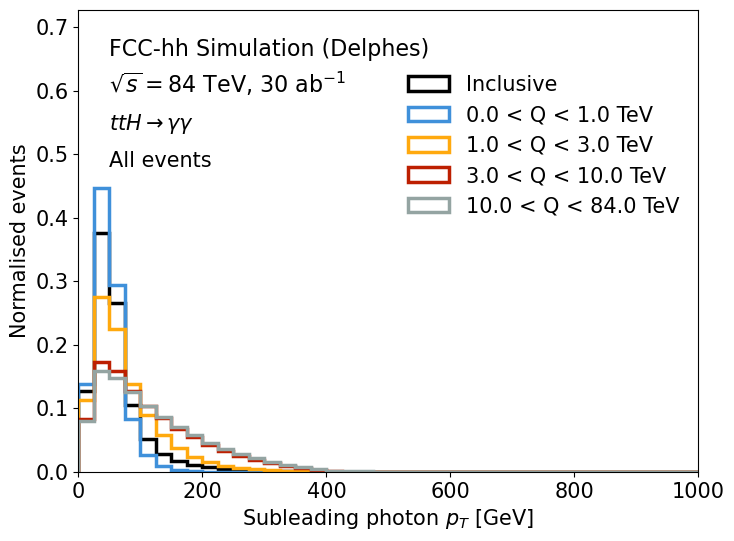

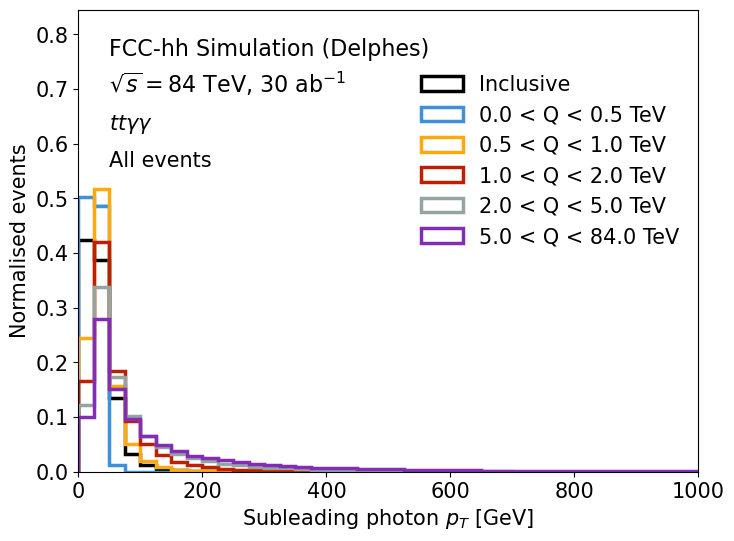

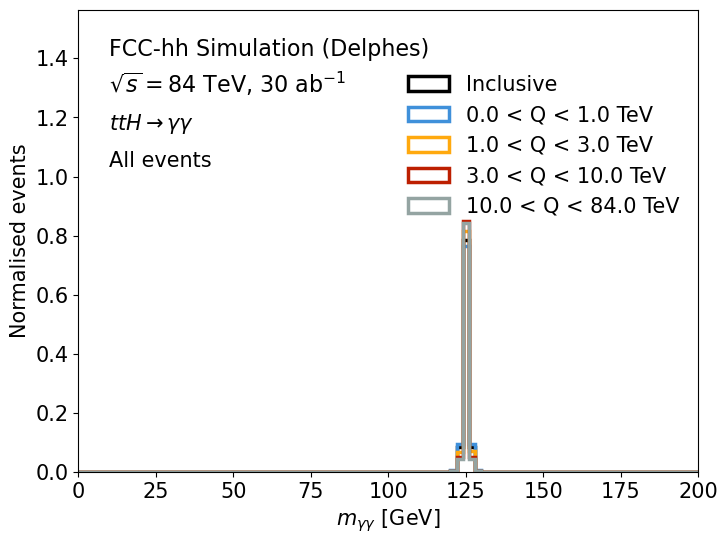

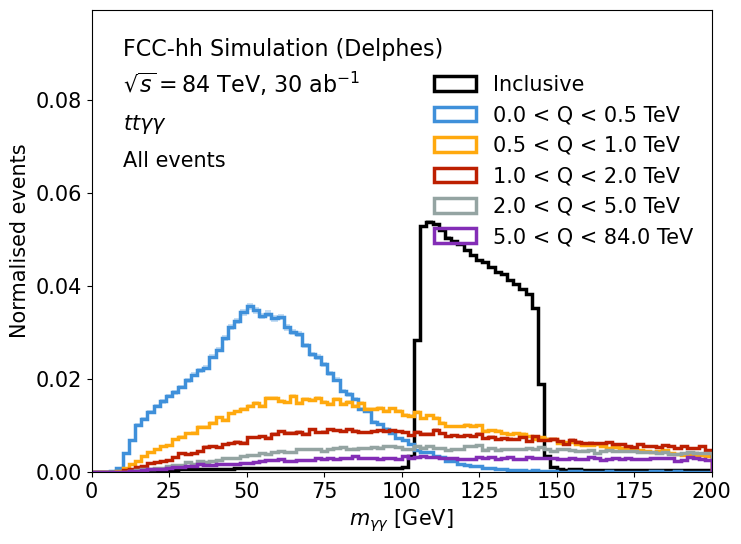

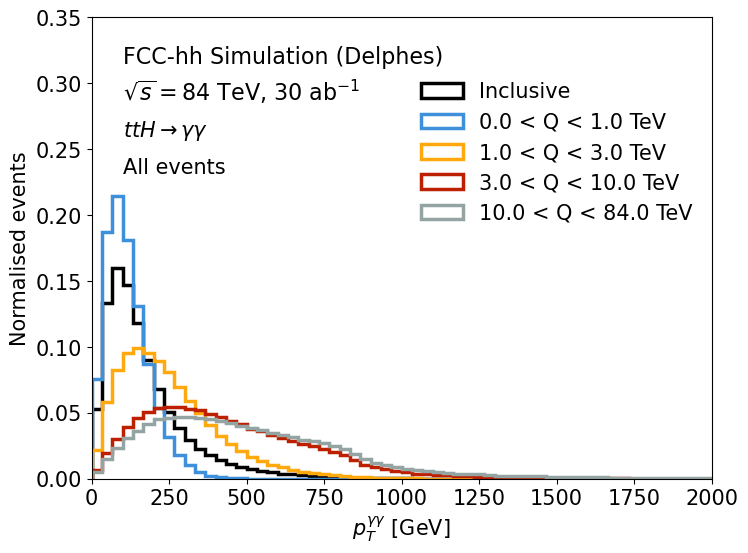

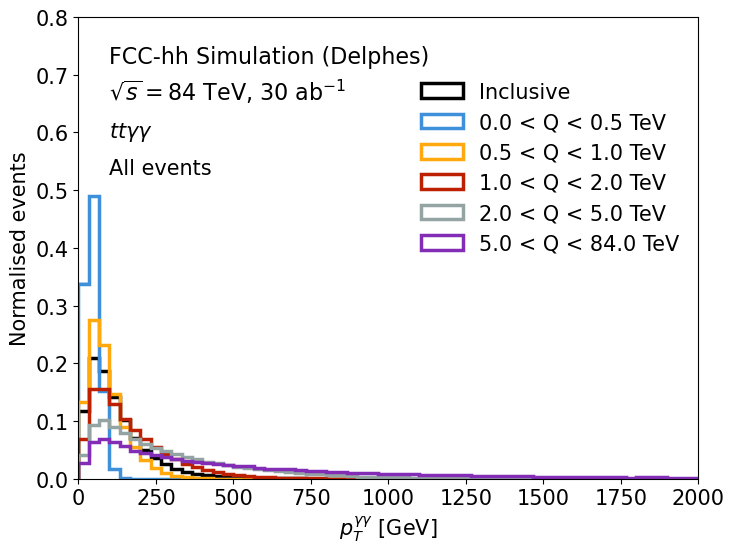

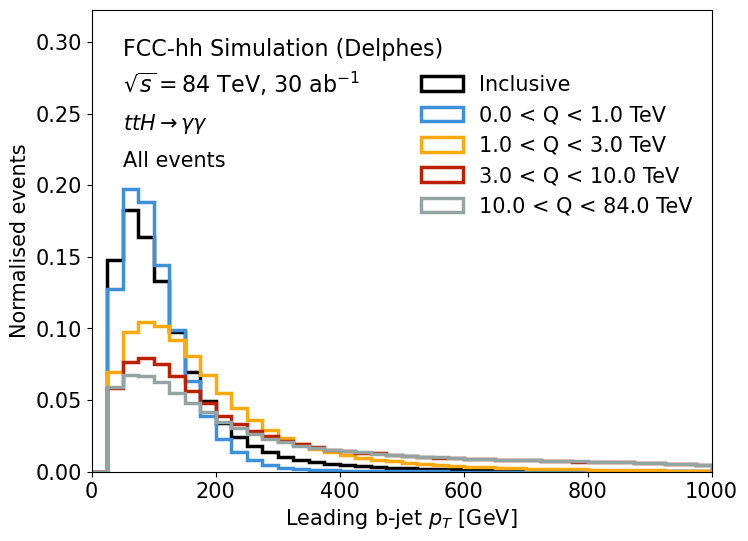

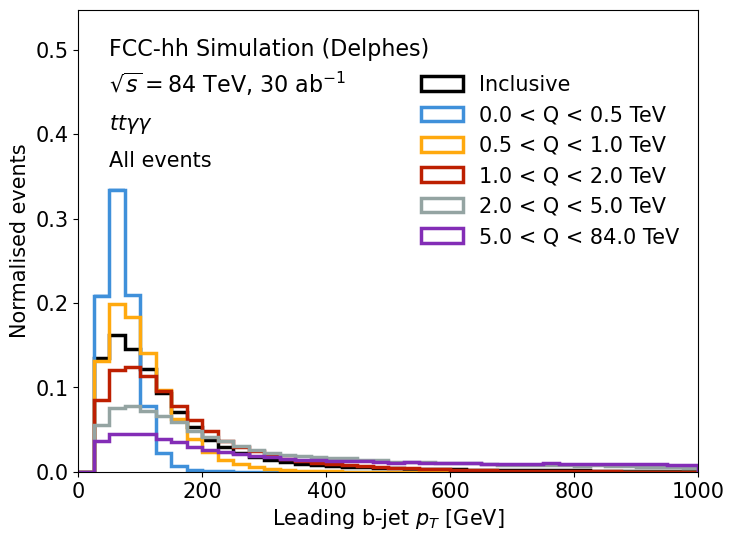

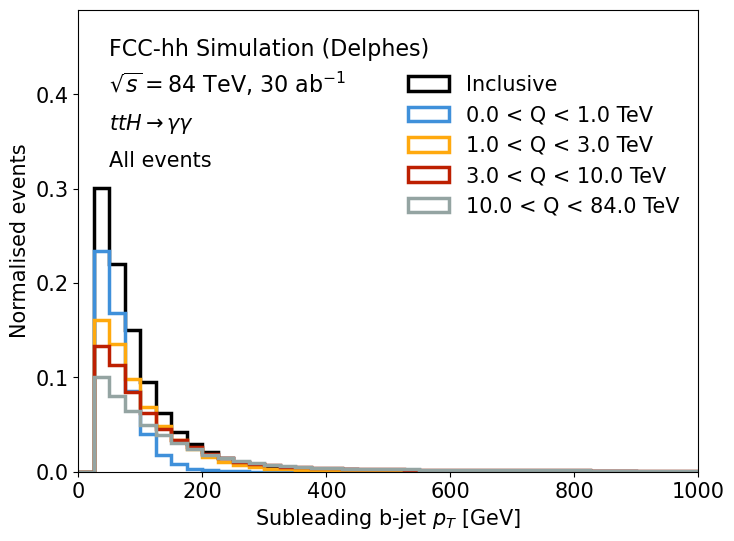

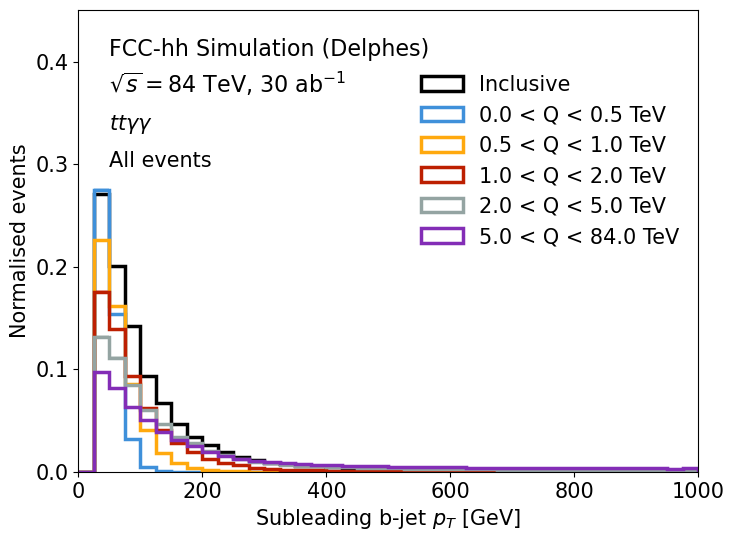

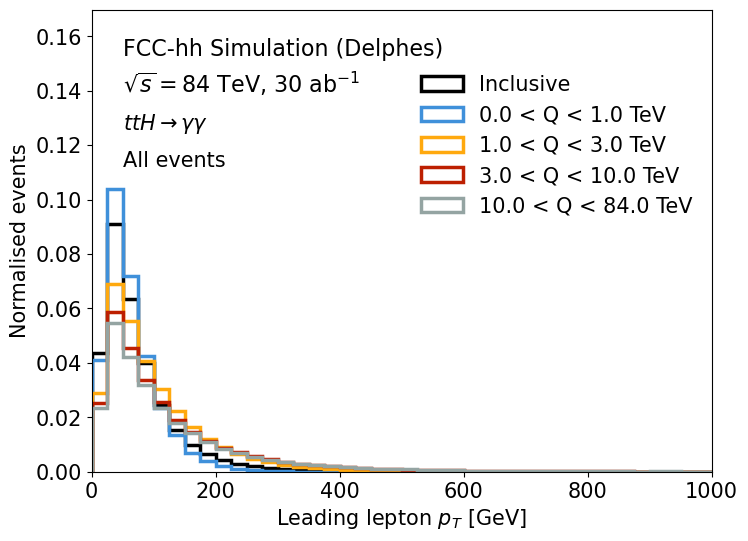

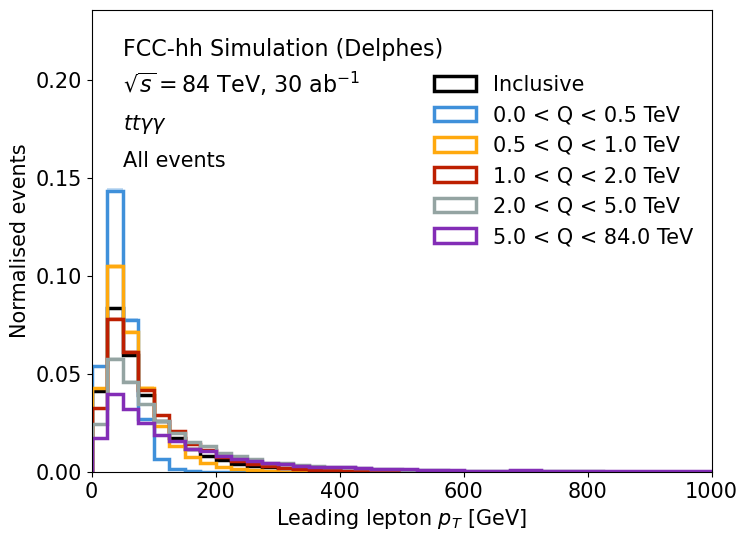

In [35]:
for variable, infos in variables_dicts.items() :
    if variable in variables_list :
        pass
    else :
        continue
    for p in list(PROCESS.keys()) :
        process_label = PROCESS[p]["label"]
        fig, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(8,6)
        )
        # first the inclusive sample in black
        bin_values, bin_edges, _ = ax.hist(dfs["incl"][p][variable], 
                                           weights=dfs["incl"][p]["weight"]/dfs["incl"][p]["weight"].sum(),
                                           bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                           histtype='step', linewidth=2.5, color='k',
                                           label="Inclusive")
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(dfs["incl"][p][variable], 
                                  weights=(dfs["incl"][p]["weight"]/dfs["incl"][p]["weight"].sum())**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc='k')
        # then the q-binned samples in colors
        ibin=0
        for bin, df in dfs["Qbinned"][p].items() :
            bin_labels = bin.split("_")
            bin_min = float(bin_labels[1])*1e-3
            bin_max = float(bin_labels[2])*1e-3
            bin_label = str(bin_min) + " < Q < " +str(bin_max) + " TeV"
            bin_values, bin_edges, _ = ax.hist(df[variable], 
                                               weights=df["weight"]/df["weight"].sum(),
                                               bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                               histtype='step', linewidth=2.5, color=color_sequence[ibin],
                                               label=bin_label)
            bin_unc, _ = np.histogram(df[variable], 
                                  weights=(df["weight"]/df["weight"].sum())**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            bin_unc = np.sqrt(bin_unc)
            error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[ibin])
            ibin += 1

    
        ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=15)
        ax.text(0.05, 0.66, sel_label, transform=ax.transAxes, fontsize=15)

        ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.90))
        xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Normalised events")

        #ax.set_yscale("log")
        ax.set_xlim(infos["xmin"], infos["xmax"])
        ymin,ymax = ax.get_ylim() 
        N = 0.75 if variable == "m_yy" else 0.55
        ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*N)
    
        plotname = infos["name"]+"_"+p+"_Qbinned_samples_validation_normalised_events_lin_scale_"+sel_key
        plt.savefig(os.path.join(OUTDIR, plotname+".pdf"), bbox_inches='tight')
        plt.savefig(os.path.join(OUTDIR, plotname+".png"), bbox_inches='tight')
        plt.show()

In [32]:
!mkdir /eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-07-09/plots/

In [14]:
# ok, first we apply the selection and check the statistics
SELECTIONS = {
    "selection" : "((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin1" : "(pT_yy < 60.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin2" : "(pT_yy > 60.) & (pT_yy < 120.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin3" : "(pT_yy > 120.) & (pT_yy < 200.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin4" : "(pT_yy > 200.) & (pT_yy < 300.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin5" : "(pT_yy > 300.) & (pT_yy < 450.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin6" : "(pT_yy > 450.) & (pT_yy < 600.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin7" : "(pT_yy > 600.) & (pT_yy < 1000.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin8" : "(pT_yy > 1000.) & (pT_yy < 1500.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin9" : "(pT_yy > 1500.) & (pT_yy < 2000.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    "pT_yy_bin10" : "(pT_yy > 2000.) & ((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))",
    
}

In [19]:
for p in list(PROCESS.keys()) :
    print(p)
    for sel_key, sel in SELECTIONS.items() :
        df_sel = dfs["incl"][p].query(sel)
        print(len(df_sel))

ttH
671775
100560
171022
170794
114825
71279
26479
16045
728
39
4
ttyy
50936
12936
18467
11914
5040
1896
477
196
10
0
0


In [21]:
for p in list(PROCESS.keys()) :
    print(p)
    for bin in list(SAMPLES["Qbinned"][p].keys()) :
        print(bin)
        for sel_key, sel in SELECTIONS.items() :
            df_sel = dfs["Qbinned"][p][bin].query(sel)
            print(len(df_sel))

ttH
Q_0_1000
65758
14572
23239
18773
7567
1514
76
17
0
0
0
Q_1000_3000
84425
5137
11290
18154
20922
18098
7104
3647
71
2
0
Q_3000_10000
76768
1292
3307
6948
11641
17905
14466
18953
2114
128
14
Q_10000_84000
47383
426
1205
2863
5339
9632
9442
15266
2635
425
150
ttyy
Q_0_500
86
66
18
2
0
0
0
0
0
0
0
Q_500_1000
1398
432
556
311
87
12
0
0
0
0
0
Q_1000_2000
1161
223
396
293
149
85
13
2
0
0
0
Q_2000_5000
694
124
193
161
112
66
24
14
0
0
0
Q_5000_84000
249
45
61
54
41
20
17
9
2
0
0


In [56]:
# add k-factor to ttyy sample
dfs["incl"]["ttyy"]["weight"] = dfs["incl"]["ttyy"]["weight"]*3.78

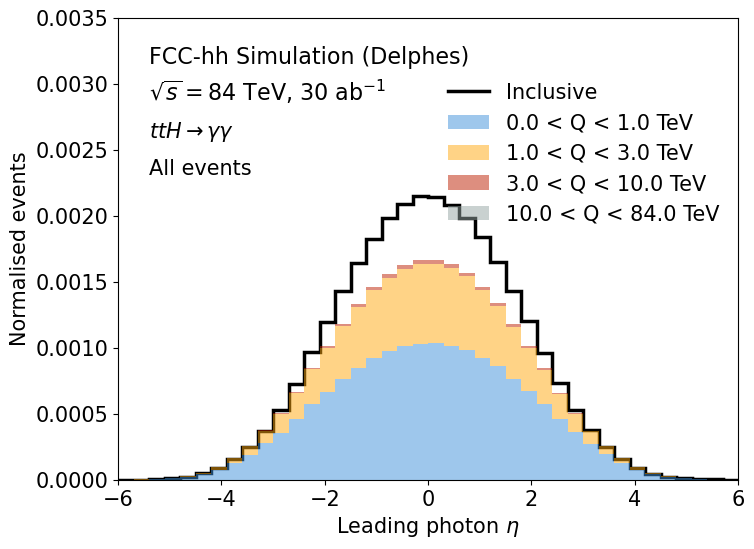

0.031000942197204916 0.025713973396742525


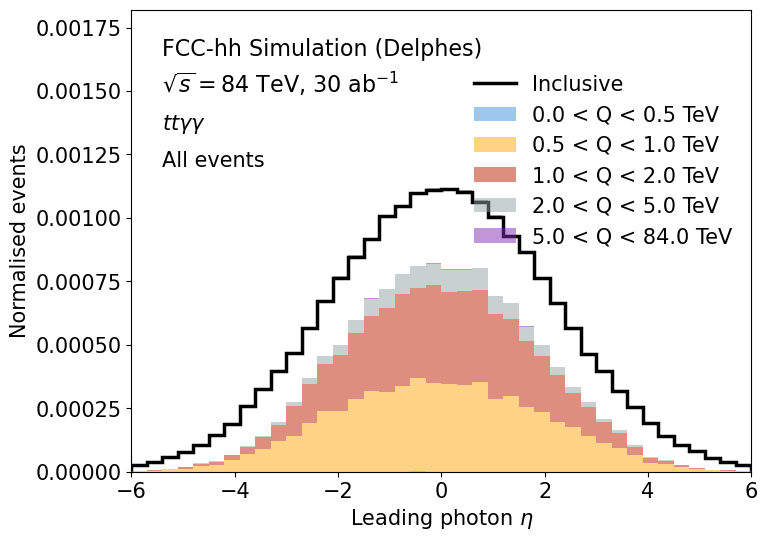

0.02026708956491884 0.013134651107579855


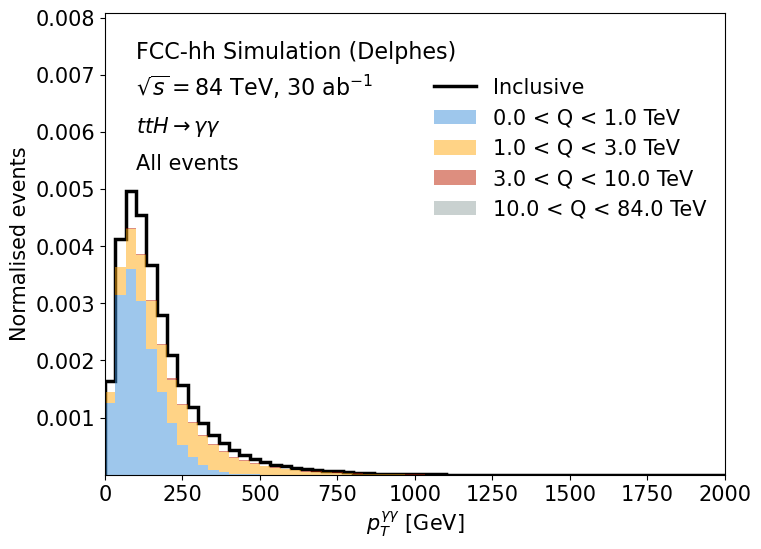

0.031000942197204916 0.025713973396742525


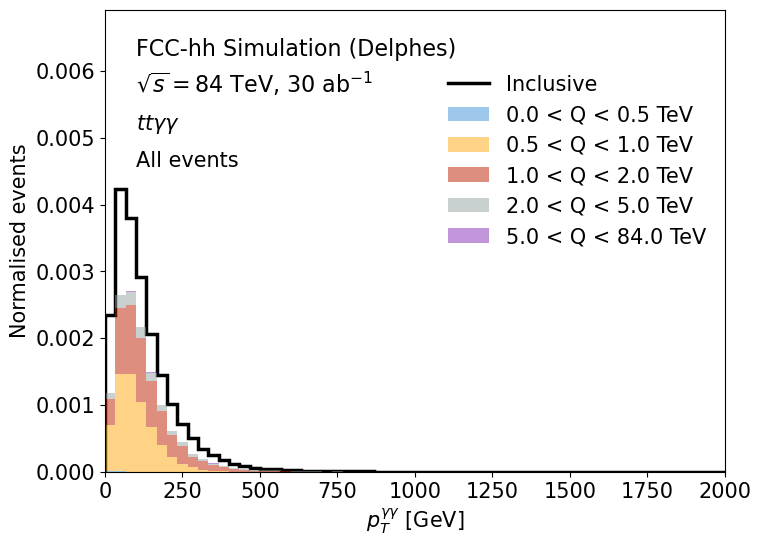

0.02026708956491884 0.013134651107579855


In [79]:
for variable, infos in variables_dicts.items() :
    if variable in ["pT_yy", "eta_y1"] :
        pass
    else :
        continue
    for p in list(PROCESS.keys()) :
        process_label = PROCESS[p]["label"]
        if p == "ttyy" :
            df_sel = dfs["incl"][p].query("m_yy>110 & m_yy<140")
        else :
            df_sel = dfs["incl"][p].copy()
        fig, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(8,6)
        )
        bin_values, bin_edges = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"],
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        # first the inclusive sample in black
        ax.stairs(bin_values, bin_edges,
                  linewidth=2.5, color='k', label="Inclusive")
        
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"]**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc='k')
        tot_incl = df_sel["weight"].sum()
        
        # then the q-binned samples in colors
        ibin=0
        baseline = 0
        tot_binned = 0
        for bin, df in dfs["Qbinned"][p].items() :
            if p == "ttyy" :
                df_sel = df.query("m_yy>110 & m_yy<140")
            else :
                df_sel = df.copy()
            bin_labels = bin.split("_")
            bin_min = float(bin_labels[1])*1e-3
            bin_max = float(bin_labels[2])*1e-3
            bin_label = str(bin_min) + " < Q < " +str(bin_max) + " TeV"
            bin_values, bin_edges = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"],
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            
            ax.stairs(bin_values+baseline, bin_edges, 
                      linewidth=0, color=color_sequence[ibin],
                      fill=True,
                      alpha=0.5,
                      label=bin_label,
                      baseline=baseline)
            
            bin_unc, _ = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"]**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            
            bin_unc = np.sqrt(bin_unc)
            #error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[ibin])
            ibin += 1
            baseline = baseline + bin_values
            tot_binned += df_sel["weight"].sum()

    
        ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=15)
        ax.text(0.05, 0.66, sel_label, transform=ax.transAxes, fontsize=15)

        ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.90))
        xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Normalised events")

        #ax.set_yscale("log")
        ax.set_xlim(infos["xmin"], infos["xmax"])
        ymin,ymax = ax.get_ylim() 
        N = 0.75 if variable == "m_yy" else 0.55
        ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*N)
    
        plotname = infos["name"]+"_"+p+"_Qbinned_samples_validation_normalisation_"+sel_key
        plt.savefig(os.path.join(OUTDIR, plotname+".pdf"), bbox_inches='tight')
        plt.savefig(os.path.join(OUTDIR, plotname+".png"), bbox_inches='tight')
        plt.show()

        print(tot_incl, tot_binned)

In [60]:
0.031000942197204916/0.025713973396742525

1.2056068394755417

In [61]:
0.07660959855539316/0.013134651107579855

5.832632928573386

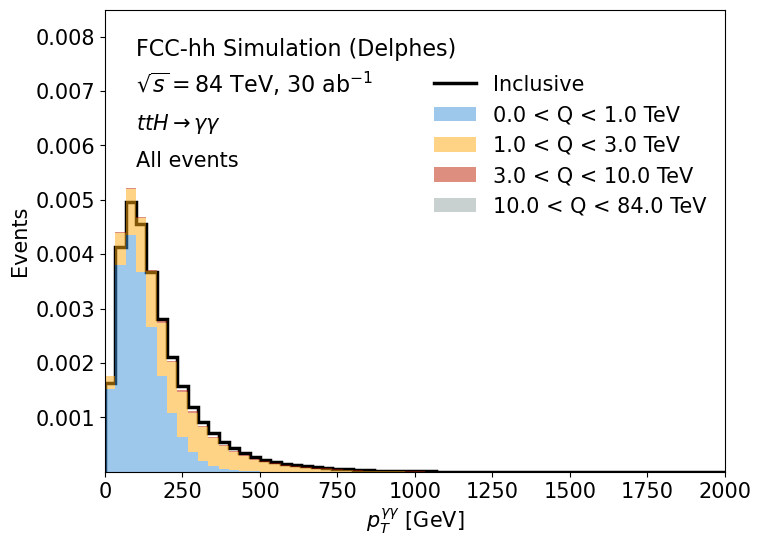

/tmp/elmazzeo/ipykernel_518393/520536752.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel["weight"] = df_sel["weight"]*5.83
/tmp/elmazzeo/ipykernel_518393/520536752.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel["weight"] = df_sel["weight"]*5.83
/tmp/elmazzeo/ipykernel_518393/520536752.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

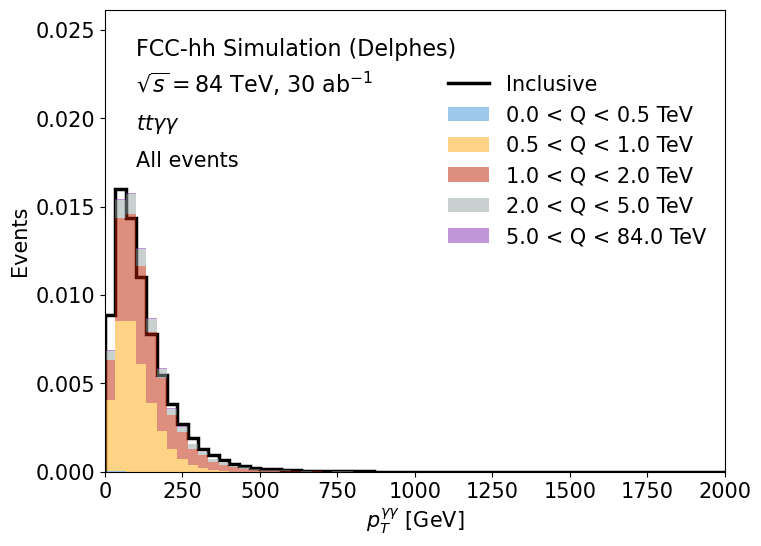

In [63]:
for variable, infos in variables_dicts.items() :
    if variable in ["pT_yy"] :
        pass
    else :
        continue
    for p in list(PROCESS.keys()) :
        process_label = PROCESS[p]["label"]
        if p == "ttyy" :
            df_sel = dfs["incl"][p].query("m_yy>110 & m_yy<140")
        else :
            df_sel = dfs["incl"][p].copy()
        fig, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(8,6)
        )
        bin_values, bin_edges = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"],
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        # first the inclusive sample in black
        ax.stairs(bin_values, bin_edges,
                  linewidth=2.5, color='k', label="Inclusive")
        
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"]**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc='k')
        tot_incl = df_sel["weight"].sum()
        
        # then the q-binned samples in colors
        ibin=0
        baseline = 0
        tot_binned = 0
        for bin, df in dfs["Qbinned"][p].items() :
            if p == "ttyy" :
                df_sel = df.query("m_yy>110 & m_yy<140")
                df_sel["weight"] = df_sel["weight"]*5.83
            else :
                df_sel = df.copy()
                df_sel["weight"] = df_sel["weight"]*1.21
            bin_labels = bin.split("_")
            bin_min = float(bin_labels[1])*1e-3
            bin_max = float(bin_labels[2])*1e-3
            bin_label = str(bin_min) + " < Q < " +str(bin_max) + " TeV"
            bin_values, bin_edges = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"],
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            
            ax.stairs(bin_values+baseline, bin_edges, 
                      linewidth=0, color=color_sequence[ibin],
                      fill=True,
                      alpha=0.5,
                      label=bin_label,
                      baseline=baseline)
            
            bin_unc, _ = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"]**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            
            bin_unc = np.sqrt(bin_unc)
            #error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[ibin])
            ibin += 1
            baseline = baseline + bin_values
            tot_binned += df_sel["weight"].sum()

    
        ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=15)
        ax.text(0.05, 0.66, sel_label, transform=ax.transAxes, fontsize=15)

        ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.90))
        xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Events")

        #ax.set_yscale("log")
        ax.set_xlim(infos["xmin"], infos["xmax"])
        ymin,ymax = ax.get_ylim() 
        N = 0.75 if variable == "m_yy" else 0.55
        ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*N)
    
        plotname = infos["name"]+"_"+p+"_Qbinned_samples_validation_normalisation_done_"+sel_key
        plt.savefig(os.path.join(OUTDIR, plotname+".pdf"), bbox_inches='tight')
        plt.savefig(os.path.join(OUTDIR, plotname+".png"), bbox_inches='tight')
        plt.show()


/tmp/elmazzeo/ipykernel_518393/744215392.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel["weight"] = df_sel["weight"]*1.21
/tmp/elmazzeo/ipykernel_518393/744215392.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel["weight"] = df_sel["weight"]*1.21
/tmp/elmazzeo/ipykernel_518393/744215392.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

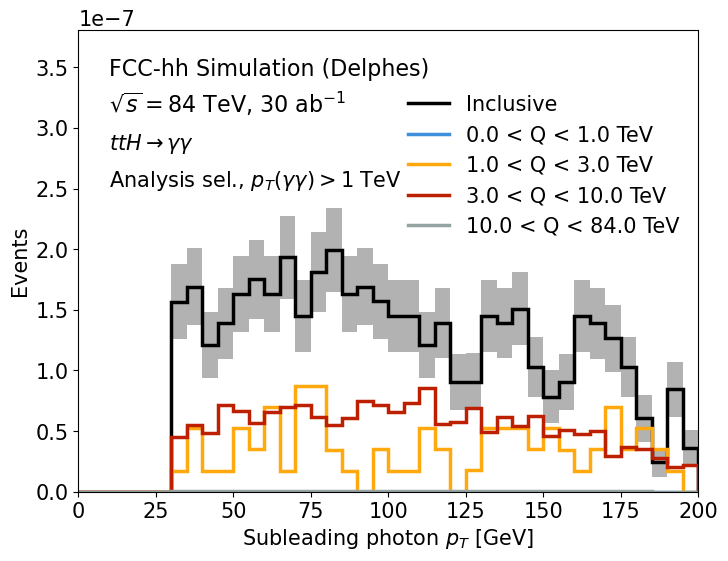

/tmp/elmazzeo/ipykernel_518393/744215392.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel["weight"] = df_sel["weight"]*5.83


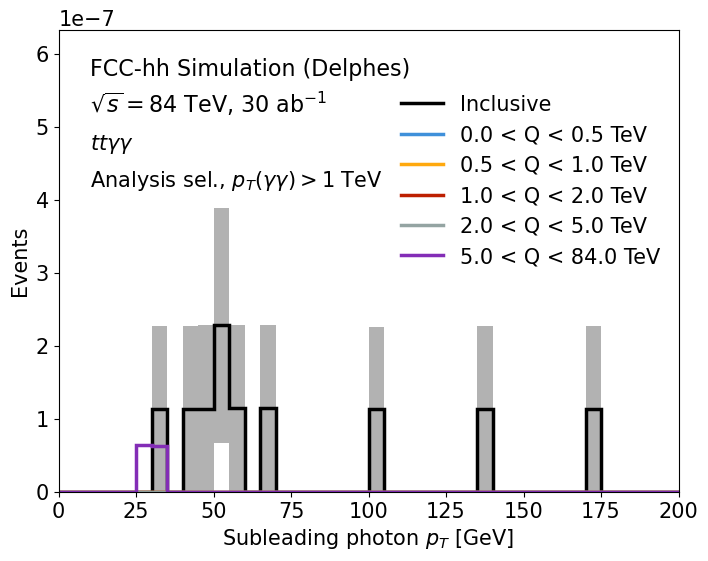

In [70]:
for variable, infos in variables_dicts.items() :
    selection = "((n_photons > 1) & (pT_y1 > 25.) & (pT_y2 > 25.) & (rel_pT_y1 > 0.35) & (rel_pT_y2 > 0.25) & (m_yy > 110.) & (m_yy <= 140.) & (n_bjets > 1) & ((n_electrons > 0) | (n_muons > 0)))"
    if variable in ["pT_y2"] :
        pass
    else :
        continue
    for p in list(PROCESS.keys()) :
        process_label = PROCESS[p]["label"]
        if p == "ttyy" :
            df_sel = dfs["incl"][p].query("m_yy>110 & m_yy<140 & pT_yy>1000. & "+ selection)
        else :
            df_sel = dfs["incl"][p].query("pT_yy>1000. & "+ selection)
        fig, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(8,6)
        )
        bin_values, bin_edges = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"],
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        # first the inclusive sample in black
        ax.stairs(bin_values, bin_edges,
                  linewidth=2.5, color='k', label="Inclusive")
        
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"]**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc='k')
        tot_incl = df_sel["weight"].sum()
        
        # then the q-binned samples in colors
        ibin=0
        baseline = 0
        tot_binned = 0
        for bin, df in dfs["Qbinned"][p].items() :
            if p == "ttyy" :
                df_sel = df.query("m_yy>110 & m_yy<140 & pT_yy>1000. & "+selection)
                df_sel["weight"] = df_sel["weight"]*5.83
            else :
                df_sel = df.query("pT_yy>1000. & "+selection)
                df_sel["weight"] = df_sel["weight"]*1.21
            bin_labels = bin.split("_")
            bin_min = float(bin_labels[1])*1e-3
            bin_max = float(bin_labels[2])*1e-3
            bin_label = str(bin_min) + " < Q < " +str(bin_max) + " TeV"
            bin_values, bin_edges = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"],
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            
            ax.stairs(bin_values, bin_edges, 
                      linewidth=0, color=color_sequence[ibin],
                      fill=False,
                      alpha=1,
                      lw=2.5,
                      label=bin_label)
            
            bin_unc, _ = np.histogram(df_sel[variable], 
                                  weights=df_sel["weight"]**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
            
            bin_unc = np.sqrt(bin_unc)
            #error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[ibin])
            ibin += 1
            baseline = baseline + bin_values
            tot_binned += df_sel["weight"].sum()

    
        ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
        ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=15)
        ax.text(0.05, 0.66, "Analysis sel., $p_T(\gamma\gamma)>1$ TeV", transform=ax.transAxes, fontsize=15)

        ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.90))
        xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Events")

        #ax.set_yscale("log")
        ax.set_xlim(infos["xmin"], infos["xmax"])
        ymin,ymax = ax.get_ylim() 
        N = 0.75 if variable == "m_yy" else 0.55
        ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*N)
    
        plotname = infos["name"]+"_"+p+"_Qbinned_samples_validation_"+sel_key
        plt.savefig(os.path.join(OUTDIR, plotname+".pdf"), bbox_inches='tight')
        plt.savefig(os.path.join(OUTDIR, plotname+".png"), bbox_inches='tight')
        plt.show()